# On Calibration of Modern Neural Networks
## Source: https://arxiv.org/abs/1706.04599
## Dataset: https://www.cs.toronto.edu/~kriz/cifar.html

Upon Loading the CIFAR-100 dataset I downloaded, I realised that I could just import it directly from Tensorflow / PyTorch. But since I already have the files, I'll just stick to pickle and cucumbers.

In [2]:
import numpy as np
import pandas as pd

# Visuals
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # for reliability diagram legend/bars

# ML
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Metrics
from sklearn.metrics import accuracy_score
from scipy.optimize import minimize_scalar  # for temperature scaling optimisation

# DL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [3]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [4]:
import os

# paths
path = os.path.expanduser(r'~\Desktop\Projects\Temperature Scaling for NN\cifar-100-python\cifar-100-python')
train_path = os.path.join(path, 'train')
test_path  = os.path.join(path, 'test')

# loading dataset
train_dict = unpickle(train_path)
test_dict = unpickle(test_path)

x_train = train_dict[b'data']
y_train = np.array(train_dict[b'fine_labels'])
x_test = test_dict[b'data']
y_test = np.array(test_dict[b'fine_labels'])

In [5]:
print(x_train.shape, y_train.shape)
print(x_test.shape,  y_test.shape)

(50000, 3072) (50000,)
(10000, 3072) (10000,)


In [6]:
# trying to reshape raw flat input (50000, 3072) -> (50000, 3, 32, 32)
x_train = x_train.reshape(-1, 3, 32, 32) # (batch size = N, channels = C, height = H, weight = W)
x_test  = x_test.reshape(-1, 3, 32, 32)

# then normalise
x_train = x_train.astype(np.float32)/255.0
x_test = x_test.astype(np.float32)/255.0

from sklearn.model_selection import train_test_split

# NTS: use 'val' instead of test to avoid data leakage while using ONLY train set 
train_idx, val_idx = train_test_split(np.arange(len(x_train)), test_size=0.1, random_state=42)

x_val, y_val = x_train[val_idx], y_train[val_idx]
x_train, y_train = x_train[train_idx], y_train[train_idx]

In [7]:
# Helper function for DataLoader
# NTS: pickle -> NumPy arrays -> TensorDataset -> DataLoader
from torch.utils.data import TensorDataset, DataLoader

def make_loader(x, y, batch_size=256, shuffle=False):
    x_t = torch.tensor(x, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(x_t, y_t),
                      batch_size=batch_size, shuffle=shuffle)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

train_loader = make_loader(x_train, y_train, shuffle=True)
val_loader = make_loader(x_val, y_val, shuffle=False)
test_loader = make_loader(x_test, y_test, shuffle=False)

Using: cpu


In [8]:
# Expected Confidence Error
def compute_ece(
        confidences: np.ndarray, # (n,)
        predictions: np.ndarray, # (n,)
        labels: np.ndarray, # (n,)
        n_bins: int = 10 # no. of conf bins
) -> float:
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1) # NoteToSelf: bins need n + 1
    ece = 0.0
    n = len(confidences)

    # 1(\hat y_i = y_i)
    correct = (predictions == labels).astype(float)

    for m in range(n_bins):
        left = bin_edges[m]
        right = bin_edges[m + 1]

        # B_m = {i : confidence_i in I_m}
        in_bin = (confidences > left) & (confidences <= right)
        bin_count = np.sum(in_bin)

        if bin_count == 0:
            continue

        # acc(B_m) = (1 / |B_m|) * sum_{i in B_m} 1(\hat y_i = y_i)
        acc_bin = np.mean(correct[in_bin])

        # conf(B_m) = (1 / |B_m|) * sum_{i in B_m} \hat p_i
        conf_bin = np.mean(confidences[in_bin])

        # ECE += (|B_m| / n) * |acc(B_m) - conf(B_m)|
        ece += (bin_count / n) * abs(acc_bin - conf_bin)
    return float(ece)

In [9]:
# Maximum Confidence Error
def compute_mce(
        confidences: np.ndarray, # (n,)
        predictions: np.ndarray, # (n,)
        labels: np.ndarray, # (n,)
        n_bins: int = 10 # no. of conf bins
) -> float:
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(confidences)

    # 1(\hat y_i = y_i)
    correct = (predictions == labels).astype(float)

    # max(M bins)
    max_gap = 0.0

    for m in range(n_bins):
        left = bin_edges[m]
        right = bin_edges[m + 1]

        # B_m = {i : confidence_i in I_m}
        in_bin = (confidences > left) & (confidences <= right)
        bin_count = np.sum(in_bin)

        if bin_count == 0:
            continue

        # acc(B_m) = (1 / |B_m|) * sum_{i in B_m} 1(\hat y_i = y_i)
        acc_bin = np.mean(correct[in_bin])

        # conf(B_m) = (1 / |B_m|) * sum_{i in B_m} \hat p_i
        conf_bin = np.mean(confidences[in_bin])

        # MCE = max_m |acc(B_m) - conf(B_m)|
        max_gap = max(max_gap, abs(acc_bin - conf_bin))
    return float(max_gap)

In [10]:
def reliability_diagram(
        confidences: np.ndarray, # (n,)
        predictions: np.ndarray, # (n,)
        labels: np.ndarray, # (n,)
        n_bins: int = 10, # no. of conf bins
        title: str = "Reliability Diagram"
) -> None:
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    width = 1.0 / n_bins

    # 1(\hat y_i = y_i)
    correct = (predictions == labels).astype(float)

    # empty warehouse
    acc_bins = []
    conf_bins = []
    counts = []

    for m in range(n_bins):
        left = bin_edges[m]
        right = bin_edges[m + 1]

        # B_m = {i : confidence_i in I_m}
        in_bin = (confidences > left) & (confidences <= right)
        bin_count = np.sum(in_bin)

        if bin_count == 0:
            acc_bins.append(0.0)
            conf_bins.append(0.0)
        else:
            acc_bins.append(np.mean(correct[in_bin]))
            conf_bins.append(np.mean(confidences[in_bin]))

        counts.append(bin_count)

    acc_bins = np.array(acc_bins)
    conf_bins = np.array(conf_bins)
    gaps = conf_bins - acc_bins  # positive -> overconfident, negative -> underconfident

    ece = compute_ece(confidences, predictions, labels, n_bins)
    mce = compute_mce(confidences, predictions, labels, n_bins)

    fig, ax = plt.subplots(figsize=(6, 6))

    # blue: accuracy per bin
    ax.bar(bin_centres, acc_bins, width=width * 0.9, # NTS: width * x is for gap
           color='steelblue', label='Accuracy', alpha=0.9, zorder=2) # NTS: slight transparency with alpha, zorder stacks behind

    # red: calibration gap stacked on top of accuracy
    ax.bar(bin_centres, gaps, width=width * 0.9,
           bottom=acc_bins, color='crimson',
           alpha=0.6, label='Gap', zorder=2)

    # perfect calibration diagonal
    ax.plot([0, 1], [0, 1], linestyle='--', color='black',
            linewidth=1.5, label='Perfect calibration', zorder=3)

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title}\nECE={ece:.3f}  MCE={mce:.3f}')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

In [11]:
# Loading the model
model = models.resnet50(weights=None) # from scratch
model.fc = nn.Linear(model.fc.in_features, 100) # use 100 classes for final class layer
model = model.to(device)

In [12]:
# Model training
def train(model, loader, n_epochs=20, lr=0.1, weight_decay=5e-4):
    criterion = nn.CrossEntropyLoss() # loss function
    optimizer = torch.optim.SGD(model.parameters(), lr=lr,
                                momentum=0.9, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[10, 15], gamma=0.1
    )
    model.train()

    for epoch in range(n_epochs):
        running_loss = 0.0 
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad() # accumulation by default, hence need reset
            loss = criterion(model(x_batch), y_batch)
            loss.backward() # backpropogation
            optimizer.step() # update model weights
            running_loss += loss.item() # sum of loss
        scheduler.step() # update learning rate scheduler after each epoch
        print(f'Epoch {epoch+1}/{n_epochs}  loss: {running_loss/len(loader):.4f}')

train(model, train_loader)

Epoch 1/20  loss: 5.8574
Epoch 2/20  loss: 4.4926
Epoch 3/20  loss: 4.2422
Epoch 4/20  loss: 3.9184
Epoch 5/20  loss: 3.6505
Epoch 6/20  loss: 3.4237
Epoch 7/20  loss: 3.2997
Epoch 8/20  loss: 3.0672
Epoch 9/20  loss: 2.8838
Epoch 10/20  loss: 2.7207
Epoch 11/20  loss: 2.2453
Epoch 12/20  loss: 2.0396
Epoch 13/20  loss: 1.8842
Epoch 14/20  loss: 1.7347
Epoch 15/20  loss: 1.5386
Epoch 16/20  loss: 1.1305
Epoch 17/20  loss: 0.9935
Epoch 18/20  loss: 0.9054
Epoch 19/20  loss: 0.8252
Epoch 20/20  loss: 0.7445


In [13]:
# Obtaining results from model evaluation
def get_logits_and_labels(model, loader, device):
    model.eval() # pause for evaluation
    all_logits, all_labels = [], [] # initialisation

    with torch.no_grad(): # don't compute gradients
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch) # logits needed for calibration later
            all_logits.append(logits.cpu().numpy())
            all_labels.append(y_batch.numpy())

    return np.concatenate(all_logits), np.concatenate(all_labels)

val_logits,  val_labels = get_logits_and_labels(model, val_loader,  device)
test_logits, test_labels = get_logits_and_labels(model, test_loader, device)

In [14]:
# Temperature scaling
class TemperatureScaler:
    def __init__(self):
        self.T = 1.0
        
    # computing logits -> softmax probabilites
    def _softmax(self, logits): 
        shifted = logits - logits.max(axis=1, keepdims=True)  # subtract largest value from all for numerical stability
        exp = np.exp(shifted)
        return exp / exp.sum(axis=1, keepdims=True) # normalise into probabilities

    # find T* by minimising NLL on val logits
    def fit(self, logits, labels):
        def nll(T): 
            probs = self._softmax(logits / T)
            true_probs = probs[np.arange(len(labels)), labels]
            return -np.sum(np.log(true_probs + 1e-12)) # negative log-likelihood

        result = minimize_scalar(nll, bounds=(0.05, 10.0), method='bounded') # bounded by temperature = [0.05,10]
        self.T = result.x # best temperature after optimisation
        print(f'Optimal temperature: {self.T:.4f}')
        return self.T

    # apply T* and return confidences + predictions
    def calibrate(self, logits):
        probs = self._softmax(logits / self.T)
        return probs.max(axis=1), probs.argmax(axis=1)

scaler = TemperatureScaler()
scaler.fit(val_logits, val_labels)

Optimal temperature: 1.7949


np.float64(1.7949433275443079)

ECE before: 0.2117
ECE after: 0.0314
MCE before: 0.3162
MCE after: 0.1272


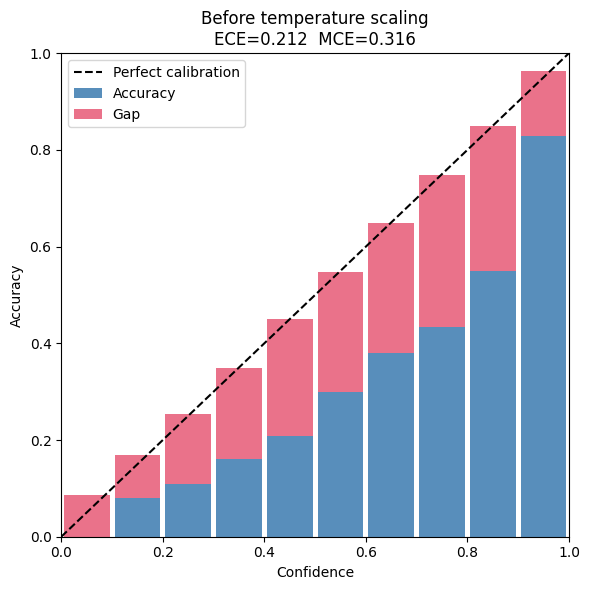

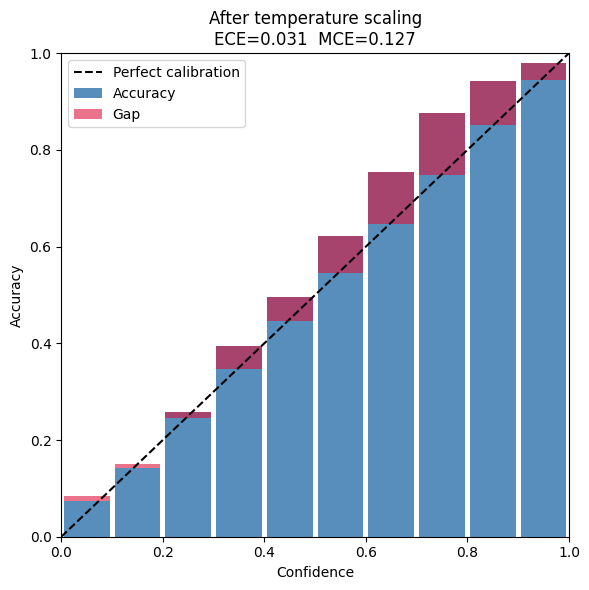

In [15]:
# Full comparison on confidence, predictions before and after temperature scaling
def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)

# before
probs_before = softmax(test_logits)
conf_before = probs_before.max(axis=1)
preds_before = probs_before.argmax(axis=1)

# after
conf_after, preds_after = scaler.calibrate(test_logits)

print(f"ECE before: {compute_ece(conf_before, preds_before, test_labels):.4f}")
print(f"ECE after: {compute_ece(conf_after, preds_after, test_labels):.4f}")
print(f"MCE before: {compute_mce(conf_before, preds_before, test_labels):.4f}")
print(f"MCE after: {compute_mce(conf_after, preds_after, test_labels):.4f}")

reliability_diagram(conf_before, preds_before, test_labels, title="Before temperature scaling")
reliability_diagram(conf_after,  preds_after,  test_labels, title="After temperature scaling")